

# Part 2. Lifetime exposure

- GMT mapping 
- land fraction exposed function
- lifetime exposure function

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd
import pickle as pk
from scipy import interpolate
import regionmask
import glob, os, re, sys
import openpyxl
import matplotlib.pyplot as plt
import warnings
from math import ceil 
warnings.filterwarnings('ignore')

pd.set_option('display.max_rows', 20)
%matplotlib inline 

sys.path.append('../..') # location of dem4cli package
#import demographics4climate as dem4cli # to call them as dem4cli.function 
from demographics4climate import * # to call fxns directly


In [2]:
flags

{'version': 2,
 'pop_resolution': 0.1,
 'GMT_mapping': 'year_to_year',
 'cohort_sizes_source': 'UNWPP2024',
 'countrymask': 'shapefile'}

In [3]:
bbox_europe = [ 31.99,  71.09, -14.96,  34.94]


## 0) Population preprocessing

In [4]:
d_countries = preprocess_all_country_data(

    filepath_lifeexpectancy = filepath_lifeexpectancy, # life expectancy data
    start_birthyear=1950,
    end_birthyear=2025,                 # endyear is taken from end_birthyear + max life expectancy

    dir_cohortsizes = dir_cohortsizes,  # cohort size data
    data_source_cohorts='UNWPP2024',
    extend_method='linear',             # note, 'slinear' not implemented for UNWPP2024
    by_sex=False,                       # NOTE by_sex not implemented
                                            
    dir_population= dir_population,     # gridded pop data 
    ssp=2,
    urbanrural=False,                   # NOTE urbanrural not implemented for v2
    bbox = bbox_europe,                        # could use bbox europe!!

    filepath_countrymask = filepath_countrymask,    # country masks 
    data_source_countrymask = 'shapefile',
    fillcoast=False, 
    fix_smallislands=False,
    
    filepath_world_bank = filepath_world_bank_meta, # metadata 
    filepath_lookuptable = filepath_lookuptable,    # country filtering
    filter_countries=True,
    worldbank_filter=True, 
    )

    
df_countries = d_countries['info_pop']
gdf_country_borders = d_countries['borders'] 
da_regions = df_countries['region'].unique()
da_population = d_countries['population_map']
df_birthyears = d_countries['birth_years'] # NA
df_life_expectancy_5 = d_countries['life_expectancy_5']
da_cohort_size = d_countries['cohort_size']
countries_regions, countries_mask = d_countries['mask'] 

load_country_metadata took 0.11 s
load_unwpp_lifeexpectancy took 25.67 s
get_life_expectancies took 0.00 s
loading cohort sizes from UNWPP2024
load_cohort_sizes took 24.63 s
interpolate_cohortsize_countries took 0.02 s
opening compass - historical
opening compass - ssp2
load_population took 2.11 s
load_countrymask took 2.82 s
preprocess_all_country_data took 55.40 s


## 1) Load GMT stylized trajs

Showing different options : 
- extension with 10yrmean, lastyear, 10yrtrend
- Smoothing or not smoothing first decades : NOTE: OS and noOS currently not smoothed - to do? 

In [5]:
df_GMT_15, df_GMT_20, df_GMT_NDC, df_GMT_OS, df_GMT_noOS, ds_GMT_STS, df_GMT_strj = load_GMT(
    year_start=1950,
    year_end=2119,
    gmt_extend_method='10yrmean',
    smooth_first_decades=False

)


load_GMT took 9.91 s


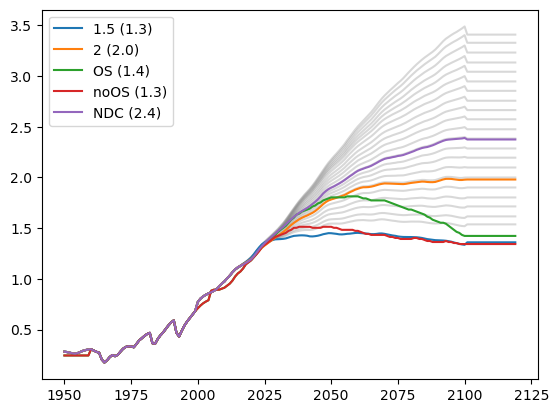

In [6]:
fig, ax = plt.subplots()

# Plot the background lines for df_GMT_strj without adding legend entries
for col in df_GMT_strj.columns:
    ax.plot(df_GMT_strj.index, df_GMT_strj[col], alpha=0.3, color='gray')  # no label

labels = ['1.5', '2', 'OS', 'noOS', 'NDC']

ax.set_prop_cycle(None)

for i, df in enumerate([df_GMT_15, df_GMT_20, df_GMT_OS, df_GMT_noOS, df_GMT_NDC]):
    labels[i] = labels[i] + ' (' + df.columns.values[0] + ')'
    df.squeeze().plot(ax=ax, label=labels[i])

plt.legend(loc='upper left')

load_GMT took 9.32 s


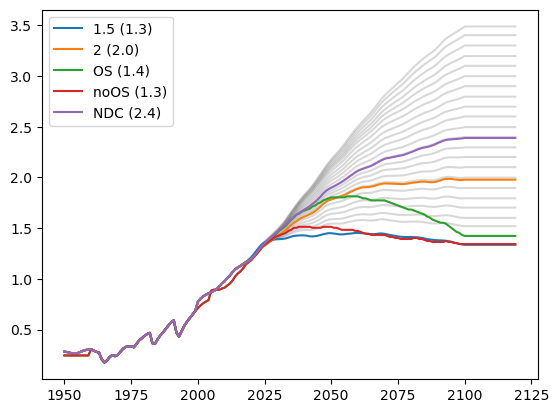

In [7]:
df_GMT_15, df_GMT_20, df_GMT_NDC, df_GMT_OS, df_GMT_noOS, ds_GMT_STS, df_GMT_strj = load_GMT(
    year_start=1950,
    year_end=2119,
    gmt_extend_method='lastyear',
    smooth_first_decades=False
)


# Plot
fig, ax = plt.subplots()

for col in df_GMT_strj.columns:
    ax.plot(df_GMT_strj.index, df_GMT_strj[col], alpha=0.3, color='gray')  # no label

labels = ['1.5', '2', 'OS', 'noOS', 'NDC']

ax.set_prop_cycle(None)

for i, df in enumerate([df_GMT_15, df_GMT_20, df_GMT_OS, df_GMT_noOS, df_GMT_NDC]):
    labels[i] = labels[i] + ' (' + df.columns.values[0] + ')'
    df.squeeze().plot(ax=ax, label=labels[i])

plt.legend(loc='upper left')


In [8]:
df_GMT_15, df_GMT_20, df_GMT_NDC, df_GMT_OS, df_GMT_noOS, ds_GMT_STS, df_GMT_strj = load_GMT(
    year_start=1950,
    year_end=2119,
    gmt_extend_method='10yrtrend',
    smooth_first_decades=False

)

load_GMT took 8.86 s


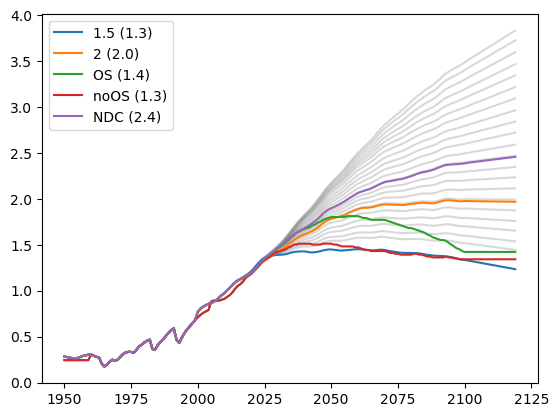

In [9]:
fig, ax = plt.subplots()

# Plot the background lines for df_GMT_strj without adding legend entries
for col in df_GMT_strj.columns:
    ax.plot(df_GMT_strj.index, df_GMT_strj[col], alpha=0.3, color='gray')  # no label

labels = ['1.5', '2', 'OS', 'noOS', 'NDC']

ax.set_prop_cycle(None)

for i, df in enumerate([df_GMT_15, df_GMT_20, df_GMT_OS, df_GMT_noOS, df_GMT_NDC]):
    labels[i] = labels[i] + ' (' + df.columns.values[0] + ')'
    df.squeeze().plot(ax=ax, label=labels[i])

plt.legend(loc='upper left')

In [10]:
df_GMT_15, df_GMT_20, df_GMT_NDC, df_GMT_OS, df_GMT_noOS, ds_GMT_STS, df_GMT_strj = load_GMT(
    year_start=1950,
    year_end=2119,
    gmt_extend_method='10yrtrend',
    smooth_first_decades=True

)

# smooth first decades

load_GMT took 9.06 s


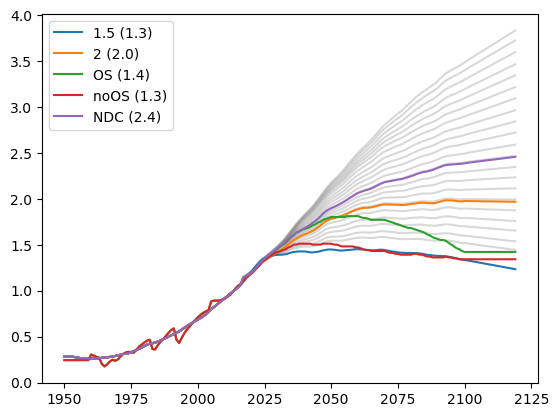

In [11]:
fig, ax = plt.subplots()

# Plot the background lines for df_GMT_strj 
for col in df_GMT_strj.columns:
    ax.plot(df_GMT_strj.index, df_GMT_strj[col], alpha=0.3, color='gray')  # no label

labels = ['1.5', '2', 'OS', 'noOS', 'NDC']

ax.set_prop_cycle(None)

for i, df in enumerate([df_GMT_15, df_GMT_20, df_GMT_OS, df_GMT_noOS, df_GMT_NDC]):
    labels[i] = labels[i] + ' (' + df.columns.values[0] + ')'
    df.squeeze().plot(ax=ax, label=labels[i])

plt.legend(loc='upper left')

## 2) Load climate data and GMT-mapping

Equivalent of old load_isimip() function. Loads in data and metadata on remapping recipe based on each trajectory



In [12]:
gmt_anomaly_correction = calc_gmt_anomaly_correction(
    filepath_gmst_obs=os.path.join(data_dir, 'gmst-obs/GCH_time_series_of_annual_global_temperatures_1850-2024_wrt_1991-2020.csv'),
    col='ERA5',
    gmt_anomaly_baseline_period=(1985,2014),)

gmt_anomaly_correction

# since the climate data is bias-adjusted to 1985-2014 rebaseline everything to this 

0.7432

In [13]:
GCMs = ['ACCESS-CM2', 'CNRM-ESM2-1', 'CanESM5', 'EC-EARTH', 'MPI-ESM1-2-HR', 'MRI-ESM2-0']
scenarios = ['ssp126', 'ssp245', 'ssp370', 'ssp585']

extremes="FWI95d" # e.g. "FWI95d"
model_names = GCMs
climatedata_dir = '/vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI' # structure should be climatedata_dir/scenario/model
filepath_model_gmst = os.path.join(data_dir, 'gmst-models/gmst_models_1850_2100_fwi.csv')
year_start=1950
year_end = 2119
gmt_anomaly_baseline_period = (1985,2014)
gmt_anomaly_correction = 0.74
rolling_window=21
min_periods=11
max_diff_valid=.2

In [14]:
d_climate_data_meta = load_climate_data(
    extremes = "FWI95d",                   # e.g. "FWI95d"
    model_names = GCMs[0:2],                # GCMs : test just for two GCMs
    df_GMT_strj =df_GMT_strj ,                # stylized trajectories
    GMT_extra_trajectories = None,
    climatedata_dir = '/vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI',     # structure should be : climatedata_dir/scenario/model/'*{model}*{extreme}.nc
    filepath_model_gmst = os.path.join(data_dir, 'gmst-models/gmst_models_1850_2100_fwi.csv'),
    scenarios = scenarios,
    smoothing=True,
    rolling_window=21,
    min_periods=11,
    gmt_anomaly_baseline_period = (1985,2014),
    gmt_anomaly_correction = 0.74,
    year_start=1950,
    year_end = 2119,            # 2025 + max life expectancy
    gmt_mapping_method = 'year-to-year', 
    max_diff_valid = .2, 
    )

Processing climate data
Processing for FWI95d


In [15]:
d_climate_data_meta

# dictionary contains the remapping recipe

{1: {'extreme': 'FWI95d',
  'model': 'ACCESS-CM2',
  'scenario': 'ssp126',
  'GMT':            tas
  1950  0.385547
  1951  0.393164
  1952  0.393677
  1953  0.379471
  1954  0.362028
  ...        ...
  2115  2.769605
  2116  2.769605
  2117  2.769605
  2118  2.769605
  2119  2.769605
  
  [170 rows x 1 columns],
  'GMT_strj_maxdiff': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]),
  'GMT_strj_valid': array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0]),
  'ind_RCP2GMT_strj': array([[ 23,  23,  23, ...,  23,  23,  23],
         [ 23,  23,  23, ...,  23,  23,  23],
         [ 23,  23,  23, ...,  23,  23,  23],
         ...,
         [ 69,  72,  75, ..., 149, 149, 149],
         [ 69,  71,  75, ..., 149, 149, 149],
         [ 69,  71,  75, ..., 149, 149, 149]])},
 2: {'extreme': 'FWI95d',
  'model': 'ACCESS-CM2',
  'scenario': 'ssp245',
  'GMT':            tas
  1950  0.385547
  1951  0.393164
  1952  0.393677
  1953  0.379471
  1954  0.362028
  

In [16]:
df_mapping = pd.DataFrame(data =d_climate_data_meta[1]['ind_RCP2GMT_strj'], columns=df_GMT_strj.columns, index=np.arange(1950,2120) )
df_mapping

# what index of the simulation is mapped to each year in each scenario

,1.5,1.6,1.7,1.8,1.9,2.0,2.1,2.2,2.3,2.4,...,2.6,2.7,2.8,2.9,3.0,3.1,3.2,3.3,3.4,3.5
1950,23,23,23,23,23,23,23,23,23,23,...,23,23,23,23,23,23,23,23,23,23
1951,23,23,23,23,23,23,23,23,23,23,...,23,23,23,23,23,23,23,23,23,23
1952,23,23,23,23,23,23,23,23,23,23,...,23,23,23,23,23,23,23,23,23,23
1953,23,23,23,23,23,23,23,23,23,23,...,23,23,23,23,23,23,23,23,23,23
1954,23,23,23,23,23,23,23,23,23,23,...,23,23,23,23,23,23,23,23,23,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2115,69,72,75,78,81,84,87,91,95,100,...,130,149,149,149,149,149,149,149,149,149
2116,69,72,75,78,81,84,87,92,95,100,...,131,149,149,149,149,149,149,149,149,149
2117,69,72,75,78,81,84,87,92,95,100,...,132,149,149,149,149,149,149,149,149,149
2118,69,71,75,78,81,84,87,92,95,100,...,133,149,149,149,149,149,149,149,149,149


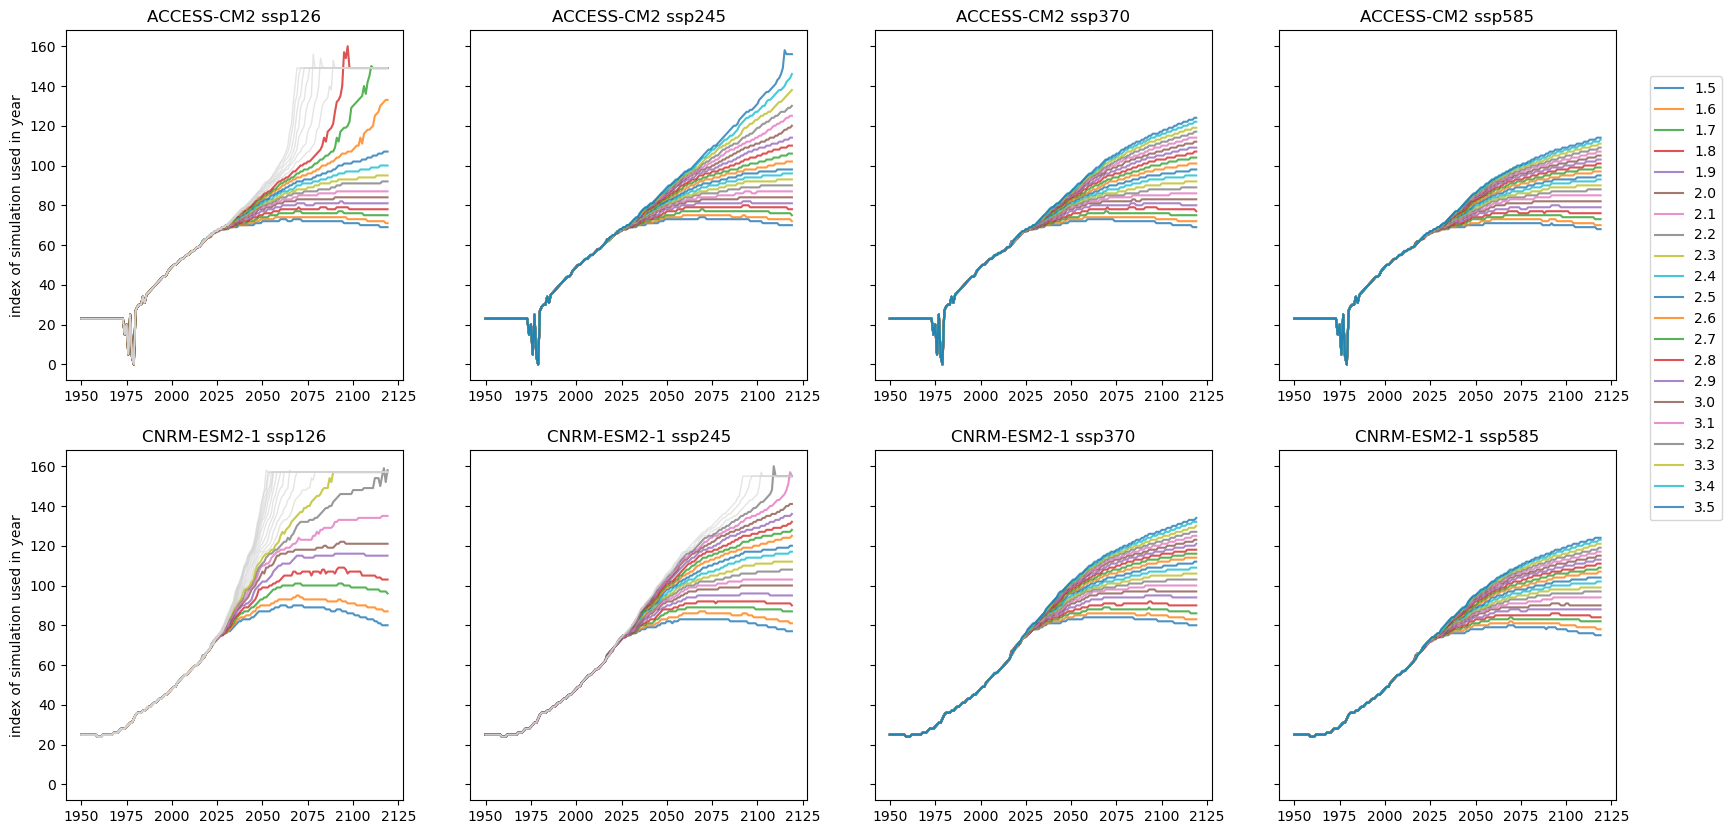

In [17]:
fig, axes = plt.subplots(2,4,figsize=(20,10),sharey=True)

axes=axes.flatten()

for i, ax in enumerate(axes):

    i+=1

    df_mapping = pd.DataFrame(data =d_climate_data_meta[i]['ind_RCP2GMT_strj'], columns=df_GMT_strj.columns, index=np.arange(1950,2120) )
    valid = np.array(d_climate_data_meta[i]['GMT_strj_valid'])  # your 0/1 array

    for col, is_valid in zip(df_mapping.columns, valid):
        if is_valid:
            ax.plot(df_mapping.index, df_mapping[col], lw=1.5, alpha=0.8,label=col)
        else:
            ax.plot(df_mapping.index, df_mapping[col], color='lightgray', lw=1.0, alpha=0.6)


    ax.set_title(d_climate_data_meta[i]['model']+' '+d_climate_data_meta[i]['scenario'])

    if i==1 or i==5:
        ax.set_ylabel('index of simulation used in year')
    
    if i==4:
        ax.legend(loc=(1.1,-.4))

    # visualize the remapping

    # gray = not valid 

#### testing different rolling window length/min period

- Window size smaller makes for a bad mapping
- min_period doesnt seem to have a big effect, ask Amaury why this was sensitive

Processing climate data
Processing for FWI95d


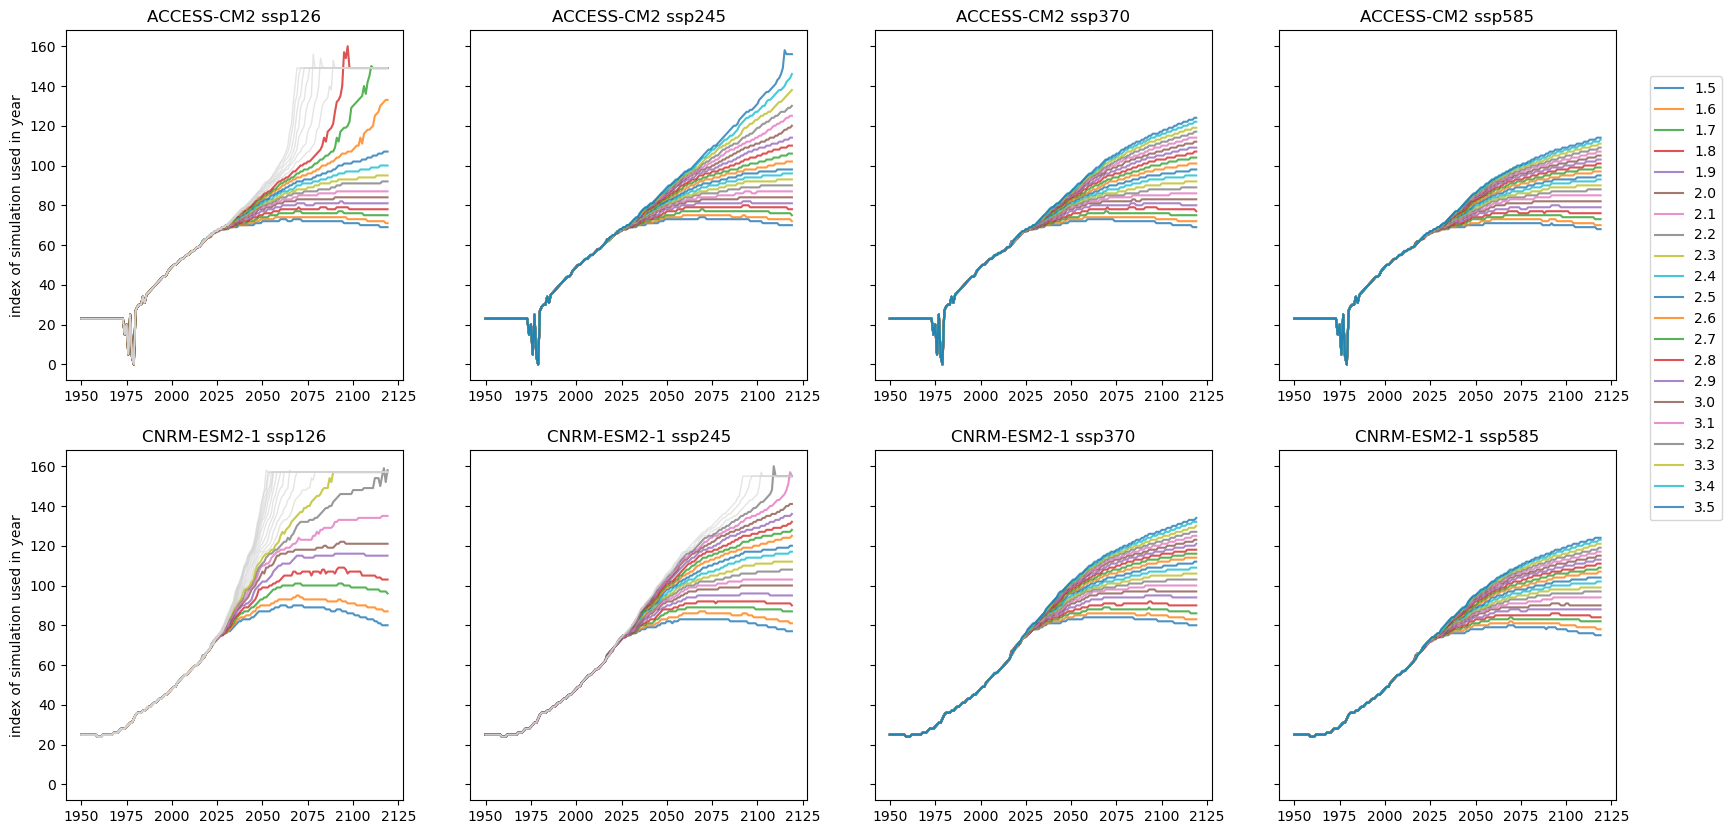

In [18]:
d_climate_data_meta = load_climate_data(
    extremes = "FWI95d",                   # e.g. "FWI95d"
    model_names = GCMs[0:2],                # GCMs
    df_GMT_strj =df_GMT_strj ,                # stylized trajectories
    GMT_extra_trajectories = None,
    climatedata_dir = '/vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI',     # structure should be : climatedata_dir/scenario/model/'*{model}*{extreme}.nc
    filepath_model_gmst = os.path.join(data_dir, 'gmst-models/gmst_models_1850_2100_fwi.csv'),
    scenarios = scenarios,
    smoothing=True,
    rolling_window=21,
    min_periods=1,
    gmt_anomaly_baseline_period = (1985,2014),
    gmt_anomaly_correction = 0.74,
    year_start=1950,
    year_end = 2119,            # 2025 + max life expectancy
    gmt_mapping_method = 'year-to-year', 
    max_diff_valid = .2, 
    )


fig, axes = plt.subplots(2,4,figsize=(20,10),sharey=True)

axes=axes.flatten()

for i, ax in enumerate(axes):

    i+=1

    df_mapping = pd.DataFrame(data =d_climate_data_meta[i]['ind_RCP2GMT_strj'], columns=df_GMT_strj.columns, index=np.arange(1950,2120) )
    valid = np.array(d_climate_data_meta[i]['GMT_strj_valid'])  # your 0/1 array

    for col, is_valid in zip(df_mapping.columns, valid):
        if is_valid:
            ax.plot(df_mapping.index, df_mapping[col], lw=1.5, alpha=0.8,label=col)
        else:
            ax.plot(df_mapping.index, df_mapping[col], color='lightgray', lw=1.0, alpha=0.6)


    ax.set_title(d_climate_data_meta[i]['model']+' '+d_climate_data_meta[i]['scenario'])

    if i==1 or i==5:
        ax.set_ylabel('index of simulation used in year')
    
    if i==4:
        ax.legend(loc=(1.1,-.4))
    

### test smoothing early years of target GMT timeseries

In [19]:
df_GMT_15, df_GMT_20, df_GMT_NDC, df_GMT_OS, df_GMT_noOS, ds_GMT_STS, df_GMT_strj = load_GMT(
    year_start=1950,
    year_end=2119,
    gmt_extend_method='10yrtrend',
    smooth_first_decades=True
)

load_GMT took 7.76 s


### load also other stylized trajs

In [20]:
GCMs = ['ACCESS-CM2', 'CNRM-ESM2-1', 'CanESM5', 'EC-EARTH', 'MPI-ESM1-2-HR', 'MRI-ESM2-0']
scenarios = ['ssp126', 'ssp245', 'ssp370', 'ssp585']


d_climate_data_meta = load_climate_data(
    extremes = "FWI95d",                   # e.g. "FWI95d"
    model_names = GCMs,                # GCMs
    df_GMT_strj =df_GMT_strj ,                # stylized trajectories- name will be column name
    GMT_extra_trajectories = [df_GMT_15, df_GMT_20, df_GMT_NDC, df_GMT_OS, df_GMT_noOS],
    GMT_extra_trajectories_names = ['15', '20', 'NDC', 'OS', 'noOS'],
    climatedata_dir = '/vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI',     # structure should be : climatedata_dir/scenario/model/'*{model}*{extreme}.nc
    filepath_model_gmst = os.path.join(data_dir, 'gmst-models/gmst_models_1850_2100_fwi.csv'),
    scenarios = scenarios,
    smoothing=True,
    rolling_window=21,
    min_periods=1,
    gmt_anomaly_baseline_period = (1985,2014),
    gmt_anomaly_correction = 0.74,
    year_start=1950,
    year_end = 2119,            # 2025 + max life expectancy
    gmt_mapping_method = 'year-to-year', 
    max_diff_valid = .2, 
    )

Processing climate data
Processing for FWI95d


## 3) Land fraction exposed

In [21]:
for i in list(d_climate_data_meta.keys()):
    scenario = d_climate_data_meta[i]['scenario']
    model = d_climate_data_meta[i]['model']
    print(i, model, scenario)

# get the names / experiments of each element of the dict

# for each dict entry you have remapping recipe for each valid target trajectory 

1 ACCESS-CM2 ssp126
2 ACCESS-CM2 ssp245
3 ACCESS-CM2 ssp370
4 ACCESS-CM2 ssp585
5 CNRM-ESM2-1 ssp126
6 CNRM-ESM2-1 ssp245
7 CNRM-ESM2-1 ssp370
8 CNRM-ESM2-1 ssp585
9 CanESM5 ssp126
10 CanESM5 ssp245
11 CanESM5 ssp370
12 CanESM5 ssp585
13 EC-EARTH ssp126
14 EC-EARTH ssp245
15 EC-EARTH ssp370
16 EC-EARTH ssp585
17 MPI-ESM1-2-HR ssp126
18 MPI-ESM1-2-HR ssp245
19 MPI-ESM1-2-HR ssp370
20 MPI-ESM1-2-HR ssp585
21 MRI-ESM2-0 ssp126
22 MRI-ESM2-0 ssp245
23 MRI-ESM2-0 ssp370
24 MRI-ESM2-0 ssp585


In [22]:
subset = dict(list(d_climate_data_meta.items())[0:2])

# test just for a subset of the simulations (faster to run)

In [23]:
GCMs = ['ACCESS-CM2', 'CNRM-ESM2-1', 'CanESM5', 'EC-EARTH', 'MPI-ESM1-2-HR', 'MRI-ESM2-0']
scenarios = ['ssp126', 'ssp245', 'ssp370', 'ssp585']
GMT_extra_trajectories_names = ['15', '20', 'NDC', 'OS', 'noOS']
climatedata_dir = '/vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI'


ds_lfe_perregion_perrun, ds_lfe_percountry_perrun, region_names = calc_landfraction_exposed(
    subset, # replace with d_climate_data_meta to run all data
    df_countries, 
    countries_regions, 
    countries_mask, 
    climatedata_dir,
    GMT_labels = df_GMT_strj.columns,
    GMT_extra_trajectories_names = GMT_extra_trajectories_names,
    year_start=1950,
    year_end=2119,
    bbox=bbox_europe,
    weights=None,
    areaweighted=True,
    convert_to_binary=False,            # if your data array is number of exceedances per year (not binary) you will get area-weighted average number of exceedances by default
                                        # if you set this to True your data is turned binary and you can get fraction of land area exposed to at least 1 day
    convert_to_binary_threshold=0,      # here you can change the threshold to e.g. get the fraction of land area exposed to at least X days 
)


# note: calling this LFE can be misleading if your data is not binary!! TODO: clarify this? 

                         🟠 Remapping Simulation 1 of 2 🟠

Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/historical/ACCESS-CM2/FWI_ACCESS-CM2_1950_2014_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/ssp126/ACCESS-CM2/FWI_ACCESS-CM2_2015_2100_FWI95d.nc
load_climate_data_array took 0.11 s
Computing land fraction exposed (LFE) for RCP 

Computing land fraction exposed (LFE) for 15                                

Computing land fraction exposed (LFE) for 20                                

Computing land fraction exposed (LFE) for NDC                               

Computing land fraction exposed (LFE) for OS                                

Computing land fraction exposed (LFE) for noOS                              

Computing land fraction exposed (LFE) for strj                              

                         🟠 Remapping Simulation 2 of 2 🟠      

In [24]:
rename_dict = {
    i: f"{subset[i]['model']} {subset[i]['scenario']}"
    for i in subset.keys()
}
rename_dict


# for plotting 

{1: 'ACCESS-CM2 ssp126', 2: 'ACCESS-CM2 ssp245'}

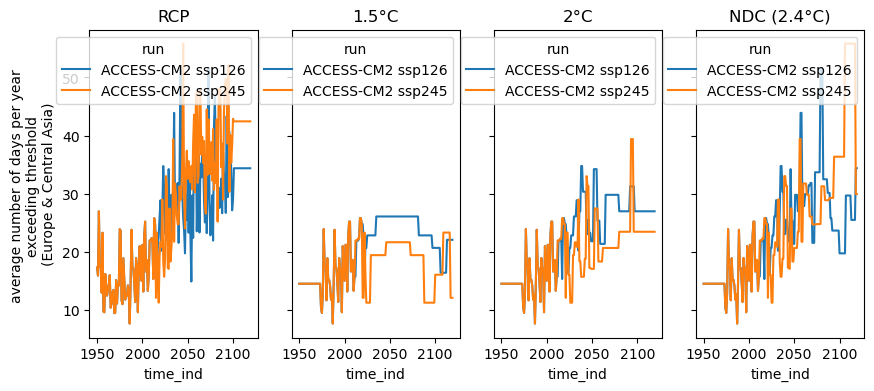

In [25]:

fig, axes = plt.subplots(1,4,sharey=True,figsize=(10,4))

ds_lfe_perregion_perrun.sel(region=0)['landfrac_peryear_perregion_RCP'].to_pandas().T.rename(columns=rename_dict).plot(ax=axes[0])
ds_lfe_perregion_perrun.sel(region=0)['landfrac_peryear_perregion_15'].to_pandas().T.rename(columns=rename_dict).plot(ax=axes[1])
ds_lfe_perregion_perrun.sel(region=0)['landfrac_peryear_perregion_20'].to_pandas().T.rename(columns=rename_dict).plot(ax=axes[2])
ds_lfe_perregion_perrun.sel(region=0)['landfrac_peryear_perregion_NDC'].to_pandas().T.rename(columns=rename_dict).plot(ax=axes[3])

labels = ['RCP', '1.5°C', '2°C',  'NDC (2.4°C)',]

for i,ax in enumerate(axes):
    ax.set_title(labels[i])
    ax.set_xticklabels([int(t + year_start) for t in ax.get_xticks()])

axes[0].set_ylabel(f'average number of days per year \nexceeding threshold \n({region_names[0]})');

## 4) Lifetime exposure 

Per run, and aggregated across runs for RCP and remapped stylized trajectories

also outputs region names and population-weighted average life-expectancy per region (should this be weighted by cohort aged 0 or total population?? - Ask Emma)


TODO: 
- aggregated across runs (median, spread etc) - DONE, some improvements possible
- subnational analysis - TODO 


In [ ]:
ds_le_percountry_perrun, ds_le_perregion_perrun, region_names, da_life_expectancy_perregion = calc_lifetime_exposure(
    subset, 
    df_countries, 
    countries_regions, 
    countries_mask, 
    climatedata_dir,
    da_population, 
    df_life_expectancy_5,
    da_cohort_size,
    GMT_labels = df_GMT_strj.columns , 
    GMT_extra_trajectories_names=GMT_extra_trajectories_names,
    start_birthyear=1950,
    end_birthyear=2025,
    year_start=1950,
    year_end=2119,
    bbox=bbox_europe
    )



                         🟠 Remapping Simulation 1 of 2 🟠

Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/historical/ACCESS-CM2/FWI_ACCESS-CM2_1950_2014_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/ssp126/ACCESS-CM2/FWI_ACCESS-CM2_2015_2100_FWI95d.nc
load_climate_data_array took 0.09 s
⏳ Computing the Population-Weighted Spatial Average of the Exposure for all countries



⏳ Computing the Population-Weighted Spatial Average of the Exposure for all regions

🟢 Population-Weighted Spatial Average of the Exposure for all countries and regions Computed
Computing lifetime exposure (LE) for RCP 

Computing lifetime exposure (LE) for 15 

Computing lifetime exposure (LE) for 20 

Computing lifetime exposure (LE) for NDC 

Computing lifetime exposure (LE) for OS 

Computing lifetime exposure (LE) for noOS 

Computing lifetime exposure (LE) for strj 

                         🟠 Remapping Simulation 2 of 2 🟠

Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/historical/ACCESS-CM2/FWI_ACCESS-CM2_1950_2014_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/ssp245/ACCESS-CM2/FWI_ACCESS-CM2_2015_2100_FWI95d.nc
load_climate_data_array took 0.08 s
⏳ Computing the Population-Weighted Spatial Average of the Exposure for all countries

⏳ Computing t

In [27]:
ds_le_percountry_perrun

<xarray.Dataset>
Dimensions:                    (run: 2, country: 52, birth_year: 76,
                                region: 52, GMT: 21)
Coordinates:
  * run                        (run) int64 1 2
  * country                    (country) object 'Albania' ... 'United Kingdom'
  * birth_year                 (birth_year) int64 1950 1951 1952 ... 2024 2025
  * GMT                        (GMT) float64 1.5 1.6 1.7 1.8 ... 3.2 3.3 3.4 3.5
Dimensions without coordinates: region
Data variables:
    le_percountry_perrun_RCP   (run, country, birth_year) float64 1.497e+03 ....
    le_percountry_perrun_15    (run, country, birth_year) float64 1.161e+03 ....
    le_percountry_perrun_20    (run, country, birth_year) float64 1.142e+03 ....
    le_percountry_perrun_NDC   (run, country, birth_year) float64 1.142e+03 ....
    le_percountry_perrun_OS    (run, country, birth_year) float64 1.118e+03 ....
    le_percountry_perrun_noOS  (run, country, birth_year) float64 1.118e+03 ....
    le_percountry_perrun_strj  (run, region, birth_year, GMT) float64 1.148e+...

In [28]:
ds_le_perregion_perrun

<xarray.Dataset>
Dimensions:                   (run: 2, region: 6, birth_year: 76, GMT: 21)
Coordinates:
  * run                       (run) int64 1 2
  * region                    (region) int64 0 1 2 3 4 5
  * birth_year                (birth_year) int64 1950 1951 1952 ... 2024 2025
  * GMT                       (GMT) float64 1.5 1.6 1.7 1.8 ... 3.2 3.3 3.4 3.5
Data variables:
    le_perregion_perrun_RCP   (run, region, birth_year) float64 1.407e+03 ......
    le_perregion_perrun_15    (run, region, birth_year) float64 1.293e+03 ......
    le_perregion_perrun_20    (run, region, birth_year) float64 1.261e+03 ......
    le_perregion_perrun_NDC   (run, region, birth_year) float64 1.275e+03 ......
    le_perregion_perrun_OS    (run, region, birth_year) float64 1.236e+03 ......
    le_perregion_perrun_noOS  (run, region, birth_year) float64 1.23e+03 ... ...
    le_perregion_perrun_strj  (run, region, birth_year, GMT) float64 1.261e+0...

In [29]:
region_names

array(['Europe & Central Asia', 'Middle East & North Africa',
       'Upper middle income', 'High income', 'Lower middle income',
       'World'], dtype=object)

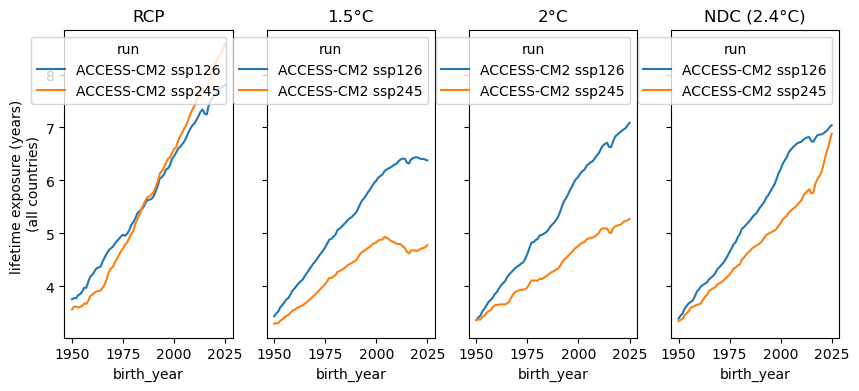

In [30]:
fig, axes = plt.subplots(1,4,sharey=True,figsize=(10,4))

(ds_le_perregion_perrun.sel(region=5)['le_perregion_perrun_RCP'].to_pandas().T /365 ).rename(columns=rename_dict).plot(ax=axes[0])
(ds_le_perregion_perrun.sel(region=5)['le_perregion_perrun_15'].to_pandas().T /365 ).rename(columns=rename_dict).plot(ax=axes[1])
(ds_le_perregion_perrun.sel(region=5)['le_perregion_perrun_20'].to_pandas().T /365 ).rename(columns=rename_dict).plot(ax=axes[2])
(ds_le_perregion_perrun.sel(region=5)['le_perregion_perrun_NDC'].to_pandas().T /365 ).rename(columns=rename_dict).plot(ax=axes[3])

labels = ['RCP', '1.5°C', '2°C',  'NDC (2.4°C)',]

for i,ax in enumerate(axes):
    ax.set_title(labels[i])

axes[0].set_ylabel(f'lifetime exposure (years) \n(all countries)');


# TODO: run for all simulations and see! 

#### aggregation function

In [1]:
ds_le_perregion_perrun_mmm = calc_lifetime_exposure_mmm(
    ds_le_perregion_perrun,
    GMT_extra_trajectories_names,
    year_ref=1950
    )

NameError: name 'calc_lifetime_exposure_mmm' is not defined

In [ ]:
# plot heatmap from median of remapped trajectories (units:years exposed)

(ds_le_perregion_perrun_mmm['median_strj']/365).sel(region=5).plot(
    cbar_kwargs={'label': 'lifetime exposure to FWI95d (years)'},
    cmap='plasma'
    )



In [ ]:
# plot % lifetime exposed 

(((ds_le_perregion_perrun_mmm['median_strj']/365) / da_life_expectancy_perregion)*100).sel(region=5).plot(
    cbar_kwargs={'label': 'lifetime exposure to FWI95d (% lifetime)'},
    cmap='plasma'
    )

## 5) Visualization functions


To do
- function for heatmap ! 
- function for EMF plot ! 